# Разведочный анализ: аргументация в кинорецензиях

Датасет[otipl2125/film_review_argumentation](https://huggingface.co/datasets/otipl2125/film_review_argumentation):

- 3280 рецензий с «Кинопоиска»
- две трёхклассовые метки — позиция автора (`NEW_grade3`, далее stance) и полярность его аргументации (`arg_label`, далее premise).

In [1]:
import sys, warnings
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

from data import GRADE_PATTERNS, LABELS, REDACTIONS, load_dataset, split_dataset
from analyze import GRADE_VALUE, GRADE_TO_LABEL

SURFACE, INK, INK_2, MUTED = "#fcfcfb", "#0b0b0b", "#52514e", "#898781"
GRID, AXIS = "#e1e0d9", "#c3c2b7"
ORDINAL = ["#86b6ef", "#2a78d6", "#0d366b"]
SERIES = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100"]
SEQUENTIAL = ["#cde2fb", "#9ec5f4", "#6da7ec", "#3987e5", "#256abf", "#184f95", "#0d366b"]

plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica Neue", "Helvetica", "Arial", "DejaVu Sans"],
    "font.size": 9, "axes.titlesize": 10.5, "axes.labelsize": 9,
    "text.color": INK, "axes.labelcolor": INK_2, "axes.titlecolor": INK,
    "xtick.color": MUTED, "ytick.color": MUTED,
    "xtick.labelcolor": INK_2, "ytick.labelcolor": INK_2,
    "axes.edgecolor": AXIS, "axes.linewidth": 0.8,
    "grid.color": GRID, "grid.linewidth": 0.8,
    "figure.dpi": 130, "savefig.bbox": "tight", "legend.frameon": False,
})

def style(ax, grid="y"):
    ax.spines[["top", "right"]].set_visible(False)
    if grid:
        ax.grid(axis=grid, zorder=0)
        ax.set_axisbelow(True)
    return ax

df = load_dataset()
raw = pd.read_csv(ROOT / "data" / "film_review_argumentation.csv")
print(f"{len(df)} рецензий, {df.movie_name.nunique()} фильмов, {raw.author.nunique()} авторов")

3280 рецензий, 323 фильмов, 2666 авторов


## 1. Состав таблицы

Из исходных 15 колонок для задачи нужны пять: текст, две метки и служебные поля
для разбиения по подгруппам.

In [ ]:
overview = pd.DataFrame({
    "колонка": df.columns,
    "тип": [str(t) for t in df.dtypes],
    "пропусков": df.isna().sum().values,
    "уникальных": df.nunique().values,
})
display(overview)

reused = raw.groupby("review_id").movie_name.nunique()
print(f"дубликатов content: {df.content.duplicated().sum()}")
print(f"неуникальных review_id: {raw.review_id.duplicated().sum()}, "
      f"из них у разных фильмов: {(reused > 1).sum()}")
print("-> review_id переиспользован у разных отзывов, дедуплицировать по нему нельзя")

,колонка,тип,пропусков,уникальных
0,review_id,int64,0,2828
1,movie_name,object,0,323
2,author,object,0,2724
3,part,object,0,2
4,content,object,0,3280
5,NEW_grade3,object,0,3
6,arg_label,object,0,3
7,century,object,0,2
8,congruent,bool,0,2
9,stance_label,int64,0,3


дубликатов content: 0
неуникальных review_id: 452, из них у разных фильмов: 307
→ review_id переиспользован у разных отзывов, дедуплицировать по нему нельзя


## 2. Баланс классов

Классы упорядочены: Bad < Neutral < Good, поэтому цвет — ординальная шкала
одного тона от светлого к тёмному, а не три произвольных цвета.

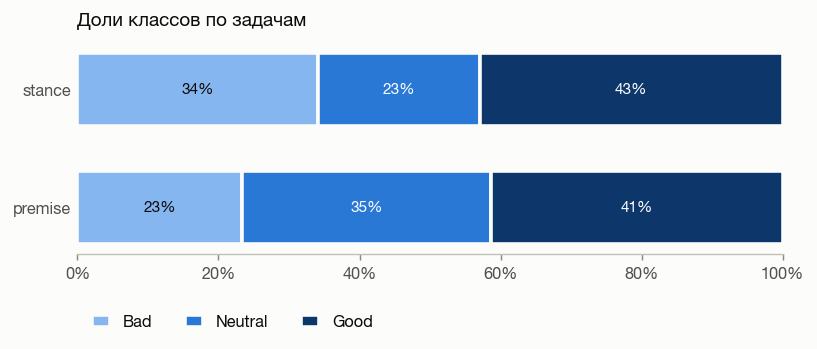

дисбаланс max/min: stance 1.88, premise 1.77


In [3]:
shares = pd.DataFrame({
    task: df[column].value_counts(normalize=True).reindex(LABELS)
    for task, column in [("stance", "NEW_grade3"), ("premise", "arg_label")]
}).T

fig, ax = plt.subplots(figsize=(7, 2.1))
left = np.zeros(len(shares))
for i, label in enumerate(LABELS):
    width = shares[label].to_numpy()
    ax.barh(shares.index, width, left=left, color=ORDINAL[i], height=0.62,
            edgecolor=SURFACE, linewidth=2, zorder=2, label=label)
    for y, (x, w) in enumerate(zip(left, width)):
        ax.text(x + w / 2, y, f"{w:.0%}", ha="center", va="center", fontsize=8.5,
                color="#ffffff" if i >= 1 else INK, zorder=3)
    left += width

ax.set_xlim(0, 1)
ax.xaxis.set_major_formatter(PercentFormatter(1))
ax.invert_yaxis()
style(ax, grid=None)
ax.spines["left"].set_visible(False)
ax.tick_params(axis="y", length=0)
ax.set_title("Доли классов по задачам", pad=10, loc="left")
ax.legend(ncol=3, loc="upper left", bbox_to_anchor=(0, -0.22), handlelength=1.1)
plt.show()

print(f"дисбаланс max/min: stance {shares.loc['stance'].max() / shares.loc['stance'].min():.2f}, "
      f"premise {shares.loc['premise'].max() / shares.loc['premise'].min():.2f}")

Метрика в задаче - macro-F1, то есть все три класса весят одинаково, а самый
редкий класс в каждой задаче разный: у stance это Neutral (23%), у premise — Bad (23%).

### Совместное распределение

Насколько позиция и аргументация вообще расходятся.

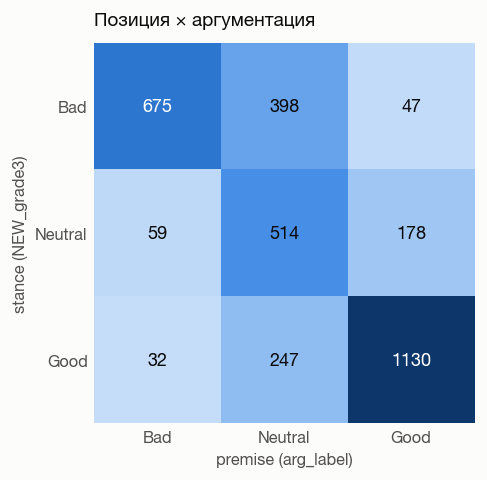

конгруэнтных (stance == premise): 70.7%
крайних расхождений Bad↔Good: 79 пар против 882 соседних


In [4]:
from matplotlib.colors import LinearSegmentedColormap

joint = pd.crosstab(df.NEW_grade3, df.arg_label).reindex(index=LABELS, columns=LABELS)
cmap = LinearSegmentedColormap.from_list("seq", SEQUENTIAL)

fig, ax = plt.subplots(figsize=(4.4, 3.8))
im = ax.imshow(joint.to_numpy(), cmap=cmap, vmin=0)
for i in range(3):
    for j in range(3):
        value = joint.iat[i, j]
        ax.text(j, i, f"{value}", ha="center", va="center", fontsize=10,
                color="#ffffff" if value > joint.to_numpy().max() * 0.55 else INK)
ax.set_xticks(range(3), LABELS)
ax.set_yticks(range(3), LABELS)
ax.set_xlabel("premise (arg_label)")
ax.set_ylabel("stance (NEW_grade3)")
ax.set_title("Позиция × аргументация", pad=10, loc="left")
ax.spines[:].set_visible(False)
ax.tick_params(length=0)
plt.show()

congruent = (df.NEW_grade3 == df.arg_label).mean()
extreme = joint.iat[0, 2] + joint.iat[2, 0]
print(f"конгруэнтных (stance == premise): {congruent:.1%}")
print(f"крайних расхождений Bad↔Good: {extreme} пар против "
      f"{joint.iat[0,1] + joint.iat[1,0] + joint.iat[1,2] + joint.iat[2,1]} соседних")

Крайние путаницы редки — 79 пар против 457 соседних. Это значит, что ординальная
структура в данных уже есть, и явно кодировать её в голове модели (CORN) почти
нечего: проверка на пяти seed'ах дала ноль.

Неконгруэнтных отзывов 29.3% — рецензент ставит высокий балл, разругав фильм,
или наоборот. Именно на них разваливается качество всех моделей.

## 3. Длина текстов

Проверяем, срабатывает ли обрезка при `max_length=512`.

токенизатор недоступен (ModuleNotFoundError), график по словам


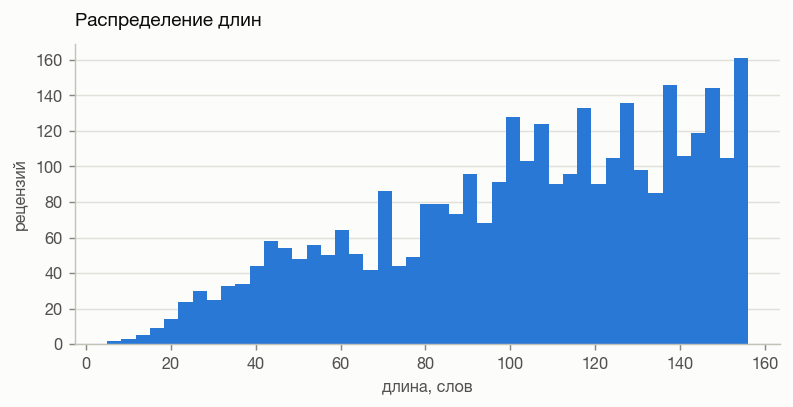

In [5]:
words = df.content.str.split().str.len()
try:
    from transformers import AutoTokenizer
    tokenizer = AutoTokenizer.from_pretrained("DeepPavlov/rubert-base-cased")
    tokens = pd.Series([len(tokenizer(t, truncation=False)["input_ids"]) for t in df.content])
except Exception as error:
    print(f"токенизатор недоступен ({type(error).__name__}), график по словам")
    tokens = None

fig, ax = plt.subplots(figsize=(7, 3))
series = tokens if tokens is not None else words
unit = "токенов (rubert-base)" if tokens is not None else "слов"
ax.hist(series, bins=45, color=SERIES[0], zorder=2)
if tokens is not None:
    ax.axvline(series.max(), color=AXIS, linewidth=1, linestyle="--", zorder=3)
    ax.annotate(f"максимум {series.max()}", xy=(series.max(), 0), xytext=(-8, 150),
                textcoords="offset points", ha="right", fontsize=8.5, color=INK_2)
ax.set_xlabel(f"длина, {unit}")
ax.set_ylabel("рецензий")
ax.set_title("Распределение длин", pad=10, loc="left")
style(ax)
plt.show()

if tokens is not None:
    for limit in (512, 320, 256):
        print(f"обрезается при max_length={limit}: {(tokens > limit).mean():.2%}")

При `max_length=512` обрезка не срабатывает ни разу — тексты короткие,
в среднем около 103 слов.

## 4. Утечка оценки в текст

Ключевой раздел. Таргет stance выведен из колонки `grade10` — балла, который
автор поставил фильму. Вопрос: не лежит ли этот балл прямо в тексте рецензии.

In [ ]:
marked = df.content.apply(lambda t: any(p.search(t) for p in GRADE_PATTERNS))
value = df.content.apply(
    lambda t: (lambda m: float(m[-1].replace(",", ".")) if m else np.nan)(GRADE_VALUE.findall(t))
)
grade10 = pd.to_numeric(raw.grade10.astype(str).str.replace(",", "."), errors="coerce")
known = value.notna() & grade10.notna()

print(f"рецензий с явной оценкой в тексте: {marked.sum()} ({marked.mean():.1%})")
print(f"извлечённое число равно колонке grade10: {(value[known] == grade10[known]).mean():.1%} "
      f"(из {known.sum()})")
print("-> в content лежит сам источник метки stance")

рецензий с явной оценкой в тексте: 1840 (56.1%)
извлечённое число равно колонке grade10: 92.8% (из 1818)
→ в content лежит сам источник метки stance


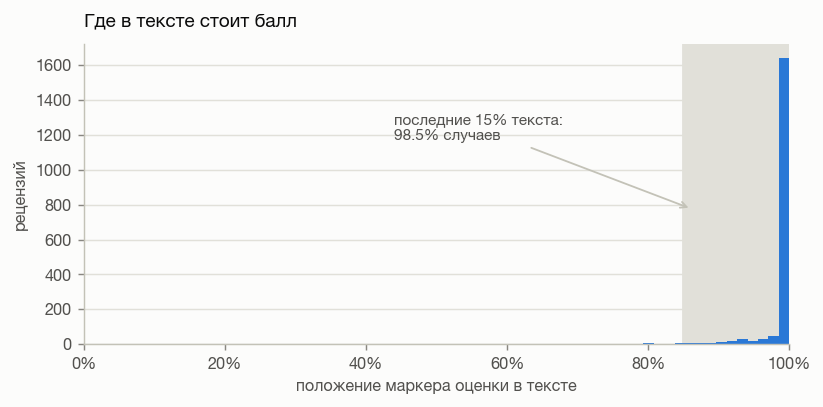

In [7]:
position = df.content[marked].apply(
    lambda t: max(m.end() for p in GRADE_PATTERNS for m in p.finditer(t)) / len(t)
)

fig, ax = plt.subplots(figsize=(7, 3))
ax.axvspan(0.85, 1.0, color=GRID, zorder=1)
ax.hist(position, bins=50, color=SERIES[0], zorder=2)
ax.set_xlim(0, 1)
ax.xaxis.set_major_formatter(PercentFormatter(1))
ax.set_xlabel("положение маркера оценки в тексте")
ax.set_ylabel("рецензий")
ax.set_title("Где в тексте стоит балл", pad=10, loc="left")
top = ax.get_ylim()[1]
ax.annotate(f"последние 15% текста:\n{(position >= 0.85).mean():.1%} случаев",
            xy=(0.862, top * 0.45), xytext=(0.44, top * 0.68), fontsize=8.5, color=INK_2,
            arrowprops=dict(arrowstyle="->", color=AXIS, linewidth=1))
style(ax)
plt.show()

Балл стоит в самом конце почти всегда. Модель с `max_length=512` видит его гарантированно.

Насколько его достаточно, чтобы предсказать класс:

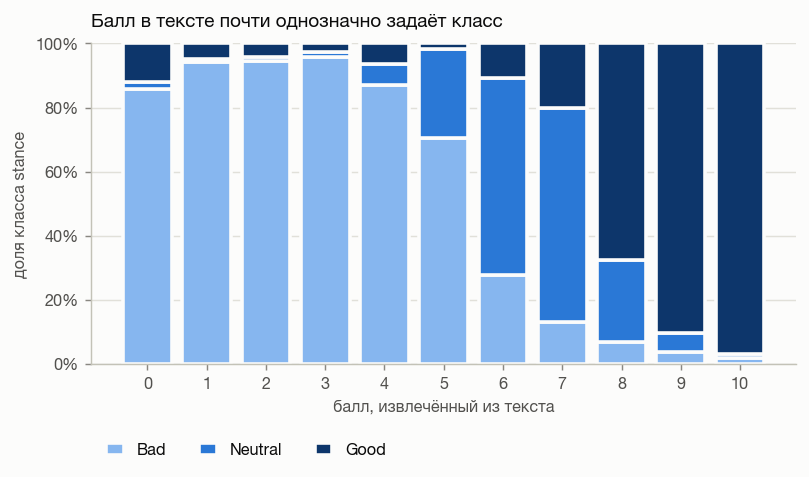

In [8]:
sub = df[value.notna()].assign(value=value[value.notna()])
grades = sub[sub.value.between(0, 10)]
table = pd.crosstab(grades.value.round().astype(int), grades.NEW_grade3)
table = table.reindex(columns=LABELS, fill_value=0)
shares_by_grade = table.div(table.sum(axis=1), axis=0)

fig, ax = plt.subplots(figsize=(7, 3.2))
bottom = np.zeros(len(shares_by_grade))
for i, label in enumerate(LABELS):
    height = shares_by_grade[label].to_numpy()
    ax.bar(shares_by_grade.index, height, bottom=bottom, color=ORDINAL[i],
           edgecolor=SURFACE, linewidth=2, zorder=2, label=label, width=0.82)
    bottom += height

ax.set_xticks(shares_by_grade.index)
ax.set_ylim(0, 1)
ax.yaxis.set_major_formatter(PercentFormatter(1))
ax.set_xlabel("балл, извлечённый из текста")
ax.set_ylabel("доля класса stance")
ax.set_title("Балл в тексте почти однозначно задаёт класс", pad=10, loc="left")
ax.legend(ncol=3, loc="upper left", bbox_to_anchor=(0, -0.2), handlelength=1.1)
style(ax)
plt.show()

In [ ]:
from sklearn.metrics import accuracy_score, f1_score

rule = sub.value.apply(lambda x: next(lab for bound, lab in GRADE_TO_LABEL if x <= bound))
rows = [{
    "задача": task,
    "n": len(sub),
    "accuracy": round(accuracy_score(sub[column], rule), 3),
    "macro-F1": round(f1_score(sub[column], rule, average="macro"), 3),
} for task, column in [("stance", "NEW_grade3"), ("premise", "arg_label")]]
display(pd.DataFrame(rows))
print("правило «≤4 -> Bad, ≤6 -> Neutral, иначе Good», без единого обученного параметра;")
print("дообученная rubert-base-cased даёт 72.44 ± 1.04 macro-F1 на stance")

,задача,n,accuracy,macro-F1
0,stance,1818,0.803,0.718
1,premise,1818,0.687,0.647


правило «≤4 → Bad, ≤6 → Neutral, иначе Good», без единого обученного параметра;
дообученная rubert-base-cased даёт 72.44 ± 1.04 macro-F1 на stance


Правило без обучения даёт 0.718 macro-F1 на stance — почти столько же, сколько
дообученный энкодер. Отсюда и вырос основной эксперимент работы: прогон
с `--redact grade`, где маркер вырезается из текста.

## 5. Шум в текстах

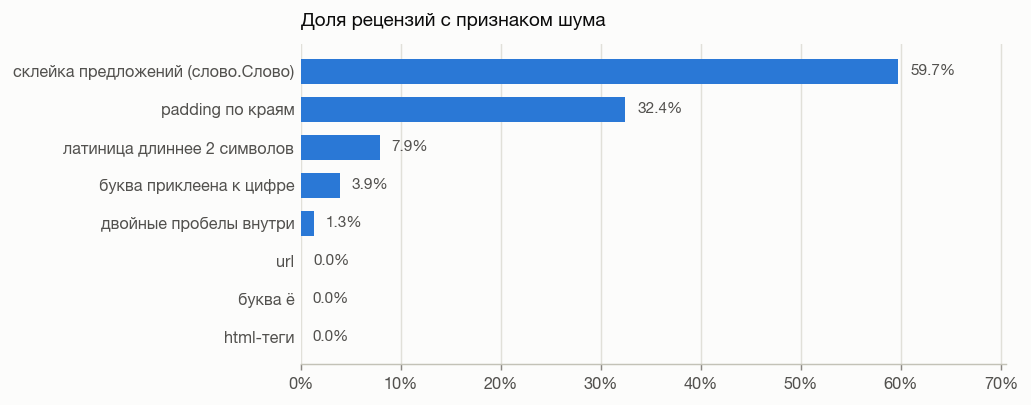

In [10]:
checks = [
    ("padding по краям", None),
    ("склейка предложений (слово.Слово)", r"[а-яa-z]\.[А-ЯA-Z]"),
    ("буква приклеена к цифре", r"[а-яa-z]\d"),
    ("двойные пробелы внутри", r"  "),
    ("латиница длиннее 2 символов", r"[A-Za-z]{3,}"),
    ("html-теги", r"<[^>]+>"),
    ("url", r"https?://"),
    ("буква ё", r"ё"),
]
noise = pd.Series({
    name: (raw.content.str.match(r"^\s|.*\s$").mean() if pattern is None
           else df.content.str.contains(pattern, regex=True).mean())
    for name, pattern in checks
}).sort_values()

fig, ax = plt.subplots(figsize=(7, 3.2))
ax.barh(noise.index, noise.to_numpy(), color=SERIES[0], height=0.66, zorder=2)
for y, share in enumerate(noise):
    ax.text(share + 0.012, y, f"{share:.1%}", va="center", fontsize=8.5, color=INK_2)
ax.set_xlim(0, max(noise) * 1.18)
ax.xaxis.set_major_formatter(PercentFormatter(1))
ax.set_title("Доля рецензий с признаком шума", pad=10, loc="left")
style(ax, grid="x")
ax.spines["left"].set_visible(False)
ax.tick_params(axis="y", length=0)
plt.show()

Главная находка здесь — склейки вида `Темнота.Чужие` в 60% текстов. Из-за них
нельзя делить текст на предложения по точке: граница предложения в `data.py`
требует пробела после точки.

HTML, URL и буквы «ё» нет — чистить нечего.

## 6. Качество разбиения

,группировка,train/val/test,фильмов теста в трейне,авторов теста в трейне
0,нет (как в статье),2296/492/492,95.5%,25.8%
1,movie_name,2463/341/476,0.0%,24.4%
2,author,2299/501/480,97.7%,0.0%


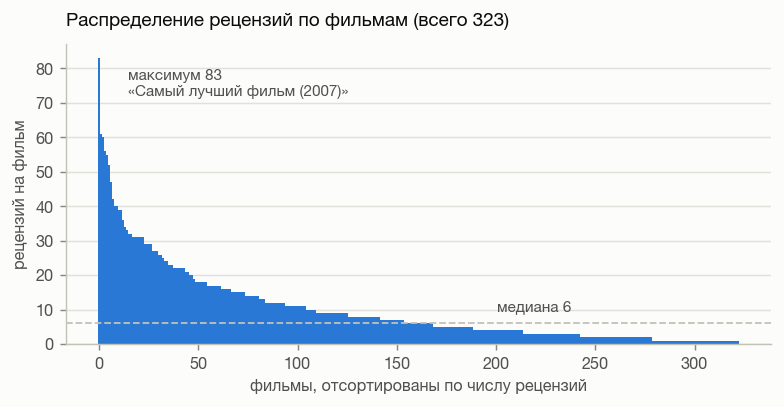

In [11]:
rows = []
for group in [None, "movie_name", "author"]:
    train, val, test = split_dataset(df, 42, group)
    rows.append({
        "группировка": group or "нет (как в статье)",
        "train/val/test": "/".join(str(len(p)) for p in (train, val, test)),
        "фильмов теста в трейне": f"{test.movie_name.isin(train.movie_name).mean():.1%}",
        "авторов теста в трейне": f"{test.author.isin(train.author).mean():.1%}",
    })
display(pd.DataFrame(rows))

per_movie = df.movie_name.value_counts()
fig, ax = plt.subplots(figsize=(7, 3))
ax.bar(range(len(per_movie)), per_movie.to_numpy(), color=SERIES[0], width=1.0, zorder=2)
ax.set_xlabel("фильмы, отсортированы по числу рецензий")
ax.set_ylabel("рецензий на фильм")
ax.set_title(f"Распределение рецензий по фильмам (всего {len(per_movie)})", pad=10, loc="left")
ax.annotate(f"максимум {per_movie.max()}\n«{per_movie.index[0]}»",
            xy=(0, per_movie.max()), xytext=(16, -6), textcoords="offset points",
            fontsize=8.5, color=INK_2, va="top")
ax.axhline(per_movie.median(), color=AXIS, linewidth=1, linestyle="--", zorder=3)
ax.annotate(f"медиана {per_movie.median():.0f}", xy=(len(per_movie) * 0.62, per_movie.median()),
            xytext=(0, 7), textcoords="offset points", fontsize=8.5, color=INK_2)
style(ax)
plt.show()

95.5% фильмов из теста встречаются и в трейне. Группировка по автору этого не чинит
(2666 авторов на 3280 рецензий, медиана — один отзыв), по фильму — чинит полностью.

Прогоны с `--group movie_name` показали, что качество при этом **не падает**:
таргет здесь — позиция конкретного рецензента, а не свойство фильма, так что
двадцать отзывов на «Бойцовский клуб» в трейне не выдают метку двадцать первого.
Утечка в этих данных одна, и она через балл, а не через фильм.

## 7. Лестница удаления текста

Насколько каждая ступень урезает текст и остаётся ли в нём оценка.

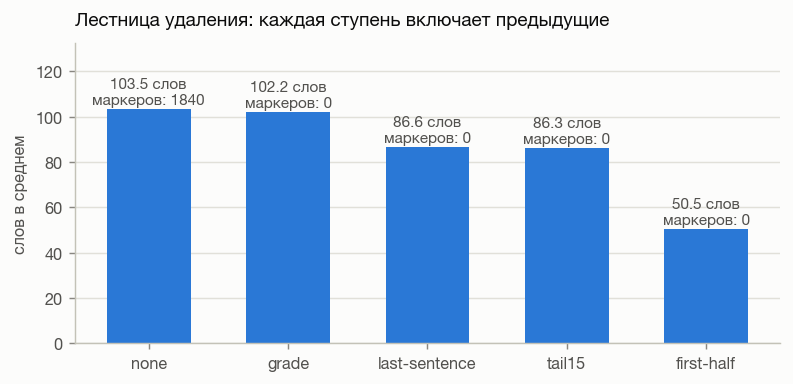

In [12]:
base = df.content.str.strip()
ladder = pd.DataFrame([{
    "ступень": name,
    "слов": text.str.split().str.len().mean(),
    "маркер оценки остался": int(text.apply(lambda t: any(p.search(t) for p in GRADE_PATTERNS)).sum()),
} for name, text in ((name, base.map(fn)) for name, fn in REDACTIONS.items())])

fig, ax = plt.subplots(figsize=(7, 3))
bars = ax.bar(ladder["ступень"], ladder["слов"], color=SERIES[0], width=0.6, zorder=2)
for bar, left in zip(bars, ladder["маркер оценки остался"]):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 2,
            f"{bar.get_height():.1f} слов\nмаркеров: {left}", ha="center",
            fontsize=8.5, color=INK_2)
ax.set_ylim(0, ladder["слов"].max() * 1.28)
ax.set_ylabel("слов в среднем")
ax.set_title("Лестница удаления: каждая ступень включает предыдущие", pad=10, loc="left")
style(ax)
plt.show()

Накопительность важна для интерпретации: начиная со ступени `grade` оценки
в текстах нет ни у одной рецензии. Значит падение качества ниже этого уровня —
потеря аргументации, а не потеря балла.

## 8. Чем это кончилось

Разведка поставила вопрос, эксперименты на него ответили. Самый дешёвый ответ —
линейный пробинг: энкодер заморожен, поверх представлений учится логистическая
регрессия, дообучения нет вовсе.

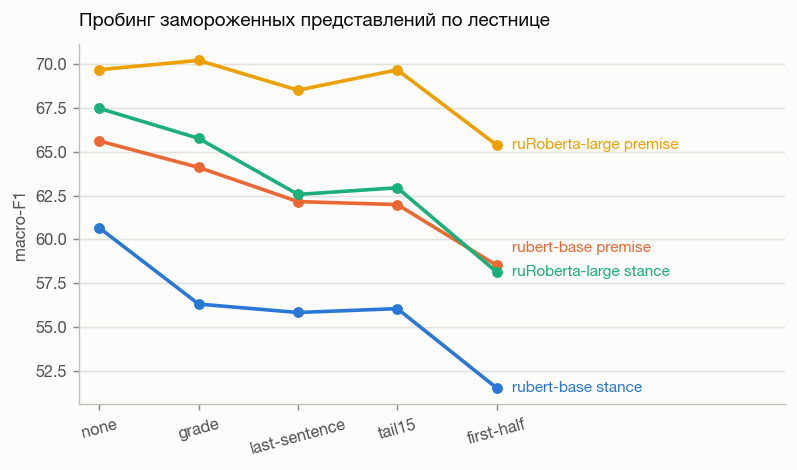

In [13]:
order = list(REDACTIONS)
probe_files = {
    "rubert-base": ROOT / "analysis" / "probe_rubert-base-cased.csv",
    "ruRoberta-large": ROOT / "analysis" / "probe_ruRoberta-large.csv",
}
if all(p.exists() for p in probe_files.values()):
    fig, ax = plt.subplots(figsize=(7, 3.6))
    lines = []
    for model, path in probe_files.items():
        pivot = pd.read_csv(path).pivot(index="redact", columns="task",
                                        values="macro-F1").reindex(order) * 100
        for task in ["stance", "premise"]:
            lines.append((f"{model} {task}", pivot[task].to_numpy()))
    ends = []
    for (name, values), color in zip(lines, SERIES):
        ax.plot(range(len(order)), values, color=color, linewidth=2,
                marker="o", markersize=5, zorder=2)
        ends.append([values[-1], name, color])

    # подписи у правого края разъезжаются, если две линии заканчиваются рядом
    ends.sort(key=lambda e: e[0])
    gap = (max(e[0] for e in ends) - min(e[0] for e in ends)) * 0.1
    for previous, current in zip(ends, ends[1:]):
        current[0] = max(current[0], previous[0] + gap)
    for y, name, color in ends:
        ax.annotate(name, xy=(len(order) - 0.85, y), fontsize=8.5, color=color, va="center")
    ax.set_xticks(range(len(order)), order, rotation=15)
    ax.set_xlim(-0.2, len(order) + 1.9)
    ax.set_ylabel("macro-F1")
    ax.set_title("Пробинг замороженных представлений по лестнице", pad=10, loc="left")
    style(ax)
    plt.show()
else:
    print("нет analysis/probe_*.csv — запустите src/probe.py")

Между `none` и `grade` удалено одно число, в среднем 1.3 слова. rubert теряет
на stance 4.35 пункта, ruRoberta — 1.71. Premise не замечает удаления балла
ни у одной модели, зато монотонно деградирует вместе с длиной текста.

Сигнал stance сосредоточен в балле, сигнал premise размазан по аргументации.
При дообучении та же пара даёт 7.73 ± 0.49 и 1.71 ± 0.46 — асимметрия
не создаётся дообучением, она уже лежит в предобученных представлениях.

## Выводы разведки

1. **В `content` лежит источник метки stance.** 56% рецензий содержат балл,
   в 92.8% случаев он равен `grade10`, и почти всегда стоит в конце текста.
   Правило без обучения даёт 0.718 macro-F1 — уровень дообученного энкодера.
2. **Классы упорядочены, но крайние путаницы редки** (79 пар против 457).
   Явное кодирование порядка в голове модели ничего не даёт.
3. **Обрезка по длине не срабатывает** — `max_length=512` избыточен.
4. **Склейки предложений в 60% текстов** — делить по точке нельзя.
5. **Сплит не групповой**, но на качество это не влияет: метка принадлежит
   рецензенту, а не фильму.
6. **`review_id` не ключ** — переиспользован у разных отзывов.